## EX 12 Face Detection using Haar Cascades with OpenCV and Matplotlib

## Name: C J Rohit

## Register No: 212224243005

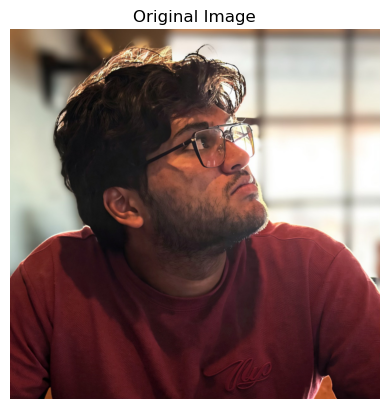

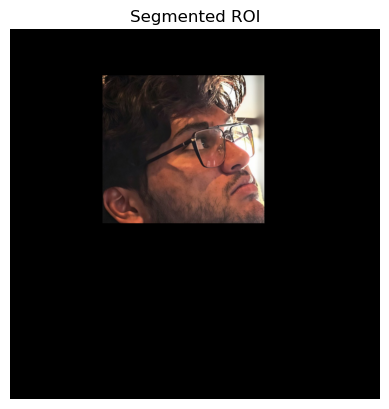

In [3]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('CJPHO.png')

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display original image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

# Define ROI
roi = image[100:420, 200:550]

# Create a blank mask
mask = np.zeros_like(image)

# Place ROI on the mask
mask[100:420, 200:550] = roi

# Perform bitwise AND
segmented_roi = cv2.bitwise_and(image, mask)

# Convert result to RGB
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)

# Display segmented ROI
plt.imshow(segmented_roi_rgb)
plt.title("Segmented ROI")
plt.axis('off')
plt.show()

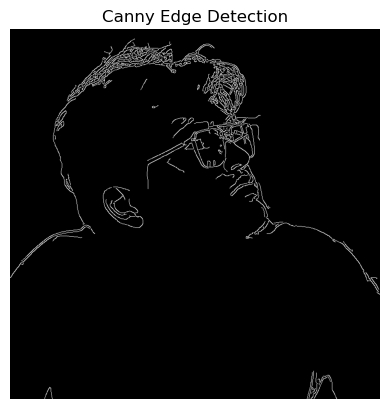

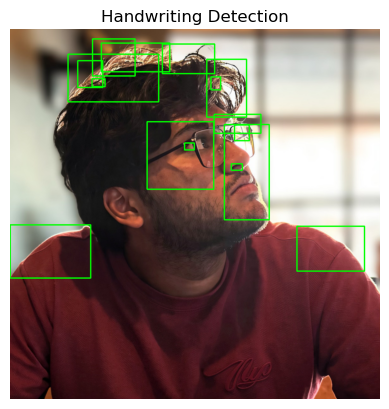

In [4]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('CJPHO.png')

# Convert image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Canny edge detection
edges = cv2.Canny(blurred_image, 50, 150)

# Display Canny edges
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

# Find contours
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Draw bounding boxes
result_image = image.copy()

for contour in contours:
    if cv2.contourArea(contour) > 50:
        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            result_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

# Display handwriting detection result
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Handwriting Detection")
plt.axis('off')
plt.show()

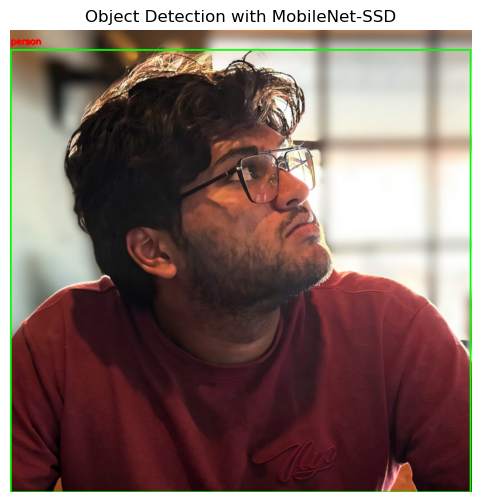

In [5]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model files
config_file = 'deploy.prototxt'
weights = 'mobilenet_iter_73000.caffemodel'

# Load pretrained MobileNet-SSD model
net = cv2.dnn.readNetFromCaffe(config_file, weights)

# Class labels
class_labels = {
    0: 'background',
    1: 'aeroplane',
    2: 'bicycle',
    3: 'bird',
    4: 'boat',
    5: 'bottle',
    6: 'bus',
    7: 'car',
    8: 'cat',
    9: 'chair',
    10: 'cow',
    11: 'diningtable',
    12: 'dog',
    13: 'horse',
    14: 'motorbike',
    15: 'person',
    16: 'pottedplant',
    17: 'sheep',
    18: 'sofa',
    19: 'train',
    20: 'tvmonitor'
}

# Read the image
image = cv2.imread('CJPHO.png')

# Get image dimensions
(h, w) = image.shape[:2]

# Convert image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a blob
blob = cv2.dnn.blobFromImage(
    image,
    0.007843,
    (300, 300),
    127.5
)

# Set input and perform detection
net.setInput(blob)
detections = net.forward()

# Draw detections
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.5:
        index = int(detections[0, 0, i, 1])
        label = class_labels[index]

        box = detections[0, 0, i, 3:7] * np.array(
            [w, h, w, h]
        )

        (startX, startY, endX, endY) = box.astype("int")

        # Draw rectangle
        cv2.rectangle(
            image_rgb,
            (startX, startY),
            (endX, endY),
            (0, 255, 0),
            2
        )

        # Draw label
        cv2.putText(
            image_rgb,
            label,
            (startX, max(20, startY - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

# Display object detection result
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Object Detection with MobileNet-SSD")
plt.axis('off')
plt.show()